<a href="https://colab.research.google.com/github/Sarkis55/CA04---Ensemble_Learning_Census_Data/blob/main/CA04_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Libaries for Preprocessing and DQA
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder

#Libraries needed for training, testing and evaluating model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score

In [ ]:
#Retrieving data and loading them into dataframe
csv_url = 'https://github.com/ArinB/MSBA-CA-03-Decision-Trees/blob/master/census_data.csv?raw=true'
df = pd.read_csv(csv_url)

display(df.head())

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0


## Preprocessing and DQA

In [ ]:
df.shape

(48842, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


In [ ]:
df.describe()

,y
count,48842.000000
mean,0.239282
std,0.426649
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
#Checking for Missing Data
df.isnull().sum()

,0
hours_per_week_bin,0
occupation_bin,0
msr_bin,0
capital_gl_bin,0
race_sex_bin,0
education_num_bin,0
education_bin,0
workclass_bin,0
age_bin,0
flag,0


In [ ]:
#Getting a value count for each column
for col in df.columns:
  print(f"Value counts for column: {col}")
  print(df[col].value_counts())
  print("\n")

Value counts for column: hours_per_week_bin
hours_per_week_bin
b. 31-40            26639
d. 41-50 & 61-70     9819
a. 0-30              7851
e. 51-60             3759
c. 71-100             774
Name: count, dtype: int64


Value counts for column: occupation_bin
occupation_bin
c. Mid - Mid     13971
b. Mid - Low     12947
e. High          12258
a. Low            7237
d. Mid - High     2429
Name: count, dtype: int64


Value counts for column: msr_bin
msr_bin
c. High    22047
b. Mid     15868
a. Low     10927
Name: count, dtype: int64


Value counts for column: capital_gl_bin
capital_gl_bin
a. = 0    42525
c. > 0     4035
b. < 0     2282
Name: count, dtype: int64


Value counts for column: race_sex_bin
race_sex_bin
c. High    29737
b. Mid     16457
a. Low      2648
Name: count, dtype: int64


Value counts for column: education_num_bin
education_num_bin
b. 9-12    30324
c. 13       8025
a. 0-8      6408
d. 14       2657
e. 15+      1428
Name: count, dtype: int64


Value counts for column: e

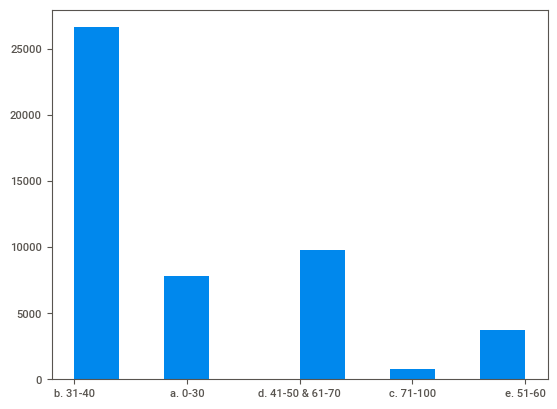

In [ ]:
plt.hist(df["hours_per_week_bin"])
plt.show()

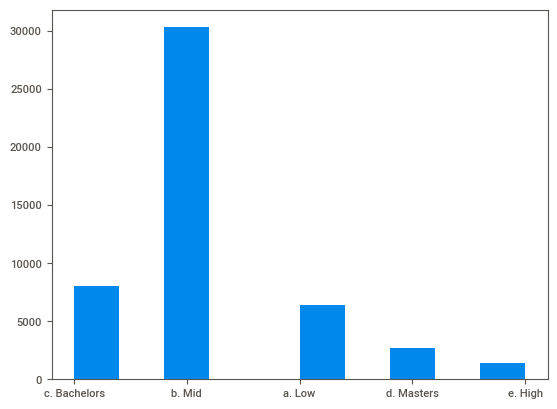

In [ ]:
plt.hist(df["education_bin"])
plt.show()

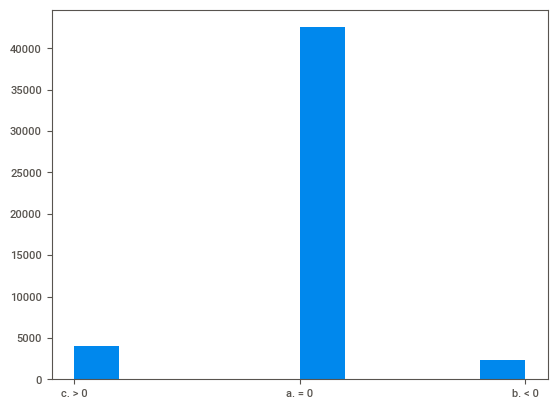

In [ ]:
plt.hist(df["capital_gl_bin"])
plt.show()

In [ ]:
#Discretizing features using label encoder.
#Since the majority of the values are object we use encoder to reprsent each value as an integer.

LE = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
      df[col] = LE.fit_transform(df[col])

print("DataFrame after encoding all object columns:")
display(df.head())

#Source: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

DataFrame after encoding all object columns:


,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,1,1,1,2,2,2,2,1,3,1,0
1,0,4,2,0,2,2,2,1,4,1,0
2,1,0,1,0,2,1,1,1,3,1,0
3,1,0,2,0,1,0,0,1,4,1,0
4,1,4,2,0,0,2,2,1,1,1,0


In [ ]:
#Getting a value count for each column after encoding
for col in df.columns:
  print(f"Value counts for column: {col}")
  print(df[col].value_counts())
  print("\n")


Value counts for column: hours_per_week_bin
hours_per_week_bin
1    26639
3     9819
0     7851
4     3759
2      774
Name: count, dtype: int64


Value counts for column: occupation_bin
occupation_bin
2    13971
1    12947
4    12258
0     7237
3     2429
Name: count, dtype: int64


Value counts for column: msr_bin
msr_bin
2    22047
1    15868
0    10927
Name: count, dtype: int64


Value counts for column: capital_gl_bin
capital_gl_bin
0    42525
2     4035
1     2282
Name: count, dtype: int64


Value counts for column: race_sex_bin
race_sex_bin
2    29737
1    16457
0     2648
Name: count, dtype: int64


Value counts for column: education_num_bin
education_num_bin
1    30324
2     8025
0     6408
3     2657
4     1428
Name: count, dtype: int64


Value counts for column: education_bin
education_bin
1    30324
2     8025
0     6408
3     2657
4     1428
Name: count, dtype: int64


Value counts for column: workclass_bin
workclass_bin
1    46012
0     2830
Name: count, dtype: int64


Val

<Axes: >

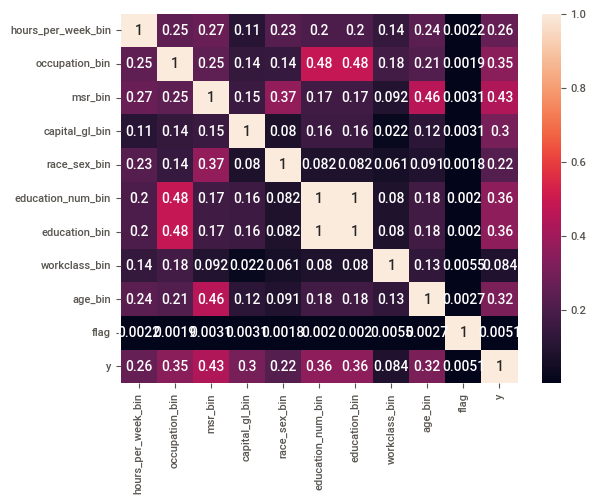

In [ ]:
#Heatmap to see feature coorelation
sns.heatmap(df.corr(), annot=True)

In [ ]:
# For Capital gl, Combining < 0 and > 0 into 1 category to help deal with the major imbalance
df["capital_gl_combined"] = (df["capital_gl_bin"] != 0).astype(int)

#Dropping capital_gl_bin
df = df.drop('capital_gl_bin', axis=1)

In [ ]:
#dropping education_bin since it is the same as education_num_bin
df = df.drop('education_bin', axis=1)

In [ ]:
#Since we have a column that labels what rows are training and testing, we manually split them by creating two separate dataframes.

#Whatever that is labeled "train" goes to the training dataframe and same for testing
train_df = df[df['flag'] == 1]
test_df = df[df['flag'] == 0]

In [ ]:
# Separate the features (X) and target (y).
# We then drop the "flag" column so that the model doesn't cheat by associating a pattern based on a speciifc value
X_train = train_df.drop(['y', 'flag'], axis=1)
y_train = train_df['y']

X_test = test_df.drop(['y', 'flag'], axis=1)
y_test = test_df['y']

#Code generated by Gemini

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

#Binning features to handle the class imbalance
binner = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

X_train['education_binned'] = binner.fit_transform(X_train[['education_num_bin']])
X_test['education_binned'] = binner.transform(X_test[['education_num_bin']])

X_train['hours_binned'] = binner.fit_transform(X_train[['hours_per_week_bin']])
X_test['hours_binned'] = binner.transform(X_test[['hours_per_week_bin']])

# Dropping the original imbalanced columns
X_train.drop(columns=['hours_per_week_bin'], inplace=True)
X_test.drop(columns=['hours_per_week_bin'], inplace=True)

X_train.drop(columns=['education_num_bin'], inplace=True)
X_test.drop(columns=['education_num_bin'], inplace=True)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


## Building Random Forest Model, then finding optimal value of n_estimators

Training the data on a random forest model, then we compare the Accuracy and AUC among different values for the 'n_estimator' hyper parameter, in order to find a value that is optimal.

In [ ]:
n_estimator_options = [50,100,150,200,250,300,350,400,450,500]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

accuracy_results = []
auc_results = []

for n_estimator in n_estimator_options:
  #Training and testing random forest model with each value for 'n_estimator'
  model = RandomForestClassifier(n_estimators = n_estimator, random_state = 101)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  #getting the accuracy and auc score
  accuracy = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  #Storing the results for accuracy and auc after each iteration
  accuracy_results.append(accuracy)
  auc_results.append(float(auc))

print("Accuracy Results:", accuracy_results)
print("AUC Results:", auc_results)

Accuracy Results: [0.8414716540753026, 0.8411645476322093, 0.8412873902094465, 0.8414716540753026, 0.8415944966525398, 0.8418401818070144, 0.8416559179411585, 0.8416559179411585, 0.8414716540753026, 0.841901603095633]
AUC Results: [0.7506608466992479, 0.7518067429572937, 0.7491034816302182, 0.7511098272640194, 0.7513698376644353, 0.7518000623523131, 0.7511406584128263, 0.7508712700739635, 0.7508404389251565, 0.7506729219711611]


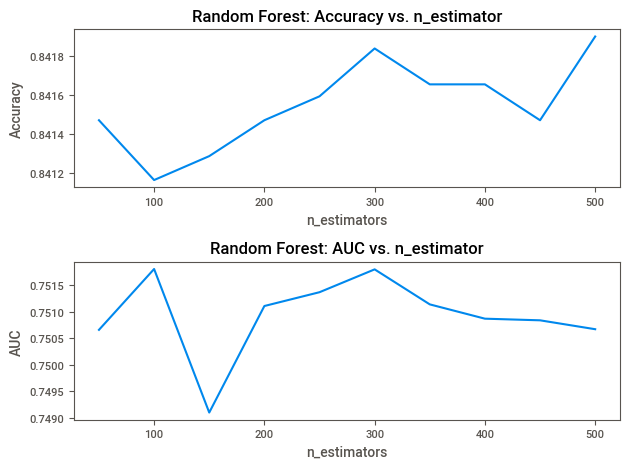

Optimal estimator Random Forest Accuracy: ( 500 , 0.841901603095633 )
Optimal estimator and Random Forest AUC: ( 100 , 0.7518067429572937 )


In [ ]:
#Plotting line graphs for Accuracy vs.n_estimator, and AUC Vs.n_estimator

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(n_estimator_options, accuracy_results)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('Random Forest: Accuracy vs. n_estimator')

ax2.plot(n_estimator_options, auc_results)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('AUC')
ax2.set_title('Random Forest: AUC vs. n_estimator')

plt.tight_layout()
plt.show()

#Storing best random forest accuacy and auc scores
best_rf_accuracy = max(accuracy_results)
best_rf_auc = max(auc_results)

#Printing best accuracy and auc and its respective estimator value
print("Optimal estimator Random Forest Accuracy: (", n_estimator_options[accuracy_results.index(best_rf_accuracy)], ',', best_rf_accuracy, ")")
print("Optimal estimator and Random Forest AUC: (", n_estimator_options[auc_results.index(best_rf_auc)], ',', best_rf_auc, ")")

#### Observations about the Random Forest Classifier’s behavior with respect to the number of estimators.
*   The random forest classifier shows a reletivly stable performance as the number of trees increase, with only a very slight increase in accuracy and the AUC curve stablizing as the number of trees increases.

#### Optimal value of the estimator within the given range?
*  An optimal value for estimators would be 100. Since accurancy is pretty consistant aroud 0.841, We notice change at the AUC line, where the performance peaks at 100 estimators, before it drops back down then increaes and stablizes.



_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

## Building Gradient Boost Model, then recording optimal estimator

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

accuracy_results = []
auc_results = []

for n_estimator in n_estimator_options:
  #Training and testing gradient boost model with each value for 'n_estimator'
  model = GradientBoostingClassifier(n_estimators = n_estimator, random_state = 101)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  #getting the accuracy and auc score
  accuracy = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  #Storing the results for accuracy and auc after each iteration
  accuracy_results.append(accuracy)
  auc_results.append(float(auc))

print("Accuracy Results:", accuracy_results)
print("AUC Results:", auc_results)

Accuracy Results: [0.8460782507217002, 0.8458939868558443, 0.8455254591241325, 0.8458939868558443, 0.845771144278607, 0.845771144278607, 0.8458939868558443, 0.8457097229899884, 0.8456483017013697, 0.8454640378355138]
AUC Results: [0.7535867321303226, 0.7549926387887843, 0.757535063766845, 0.7587640755328646, 0.7581448806806312, 0.7562591623085912, 0.7564293765960529, 0.7563985454472462, 0.756897113037718, 0.7573152624536827]


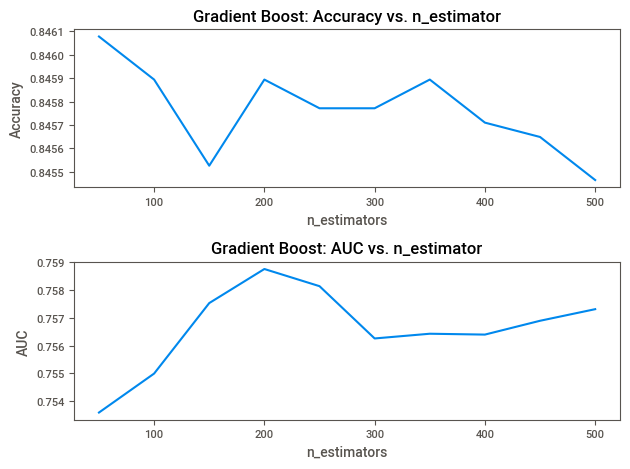

Optimal estimator Gradient Boost Accuracy: ( 50 , 0.8460782507217002 )
Optimal estimator and Gradient Boost AUC: ( 200 , 0.7587640755328646 )


In [ ]:
#Plotting line graphs for Accuracy vs. n_estimator, and AUC vs. n_estimator

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(n_estimator_options, accuracy_results)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('Gradient Boost: Accuracy vs. n_estimator')

ax2.plot(n_estimator_options, auc_results)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('AUC')
ax2.set_title('Gradient Boost: AUC vs. n_estimator')

plt.tight_layout()
plt.show()

#Storing best Adaboost accuacy and auc scores
best_gb_accuracy = max(accuracy_results)
best_gb_auc = max(auc_results)

#Printing best accuracy and auc and its respective estimator value
print("Optimal estimator Gradient Boost Accuracy: (", n_estimator_options[accuracy_results.index(best_gb_accuracy)], ',', best_gb_accuracy, ")")
print("Optimal estimator and Gradient Boost AUC: (", n_estimator_options[auc_results.index(best_gb_auc)], ',', best_gb_auc, ")")

#### Observations about the Gradient Boosting Classifier’s behavior with respect to the number of estimators.
*   Looking at the accuracy, we notice that it is highest with 50 estimators then slightly decreases as more and more trees are being included, with 500 estimators being at its lowest point. However, the AUC line seems to reveal, almost the opposite, with 50 estimators being its lowest, then reaching its peak at 200, then dropping down and very slightly improving as more trees are added. Therefore, adding more trees may slightly reduce accuracy but will improve ranking performance.

#### Optimal value of the estimator within the given range?
*   An optimal value of estimators is around 200, since at that point, AUC is at its highest while accuracy remains competitive relative to other settings.


_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

## Building AdaBoost Model, then recording optimal estimator

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

accuracy_results = []
auc_results = []

for n_estimator in n_estimator_options:
  #Training and testing Adaboost model with each value for 'n_estimator'
  model = AdaBoostClassifier(n_estimators = n_estimator, random_state = 101)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  #getting the accuracy and auc score
  accuracy = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  #Storing the results for accuracy and auc after each iteration
  accuracy_results.append(accuracy)
  auc_results.append(float(auc))

print("Accuracy Results:", accuracy_results)
print("AUC Results:", auc_results)

Accuracy Results: [0.8414716540753026, 0.8417787605183957, 0.8407960199004975, 0.843744241754192, 0.8441741907745225, 0.8438056630428107, 0.8438056630428107, 0.8440513481972852, 0.8438056630428107, 0.8438056630428107]
AUC Results: [0.7482363516494821, 0.7576863967200425, 0.7569532552110287, 0.7485567384094639, 0.7496463670368286, 0.7488663358355806, 0.7488663358355806, 0.7495659488623212, 0.7488663358355806, 0.7488663358355806]


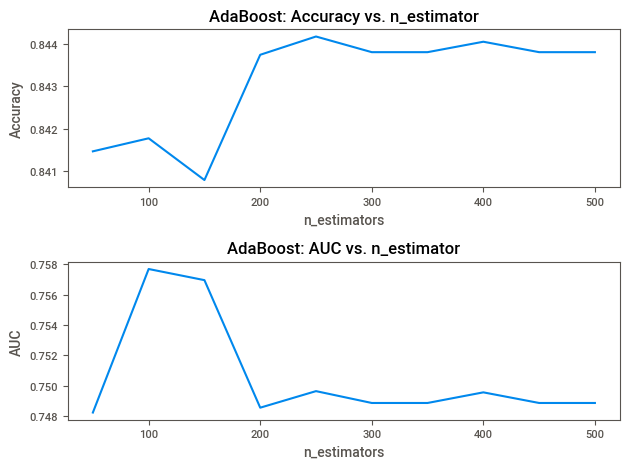

Optimal estimator and AdaBoost Accuracy: ( 250 , 0.8441741907745225 )
Optimal estimator and AdaBoost AUC: ( 100 , 0.7576863967200425 )


In [ ]:
#Plotting line graphs for Accuracy vs.n_estimator, and AUC Vs.n_estimator

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(n_estimator_options, accuracy_results)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('AdaBoost: Accuracy vs. n_estimator')

ax2.plot(n_estimator_options, auc_results)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('AUC')
ax2.set_title('AdaBoost: AUC vs. n_estimator')

plt.tight_layout()
plt.show()

#Storing best Adaboost accuacy and auc scores
best_AdaB_accuracy = max(accuracy_results)
best_AdaB_auc = max(auc_results)

#Printing best accuracy and auc and its respective estimator value
print("Optimal estimator and AdaBoost Accuracy: (", n_estimator_options[accuracy_results.index(best_AdaB_accuracy)], ',', best_AdaB_accuracy, ")")
print("Optimal estimator and AdaBoost AUC: (", n_estimator_options[auc_results.index(best_AdaB_auc)], ',', best_AdaB_auc, ")")

#### Observations about the AdaBoost Classifier’s behavior with respect to the number of estimators.
*   The AdaBoost model accuracy improves noticeably from 50 to around 200 estimators, where it reaches its peak, and then remains relatively stable through 500. In contrast, AUC peaks early at around 100 estimators, drops sharply at 200, and then stabilizes at a lower level with minor variation. This indicates that while additional estimators help improve classification accuracy, they do not translate into better ranking performance and may even slightly degrade it after the early peak.

#### Optimal value of the estimator within the given range?
*   For optimal values, it really depends on the context of the situation and what we are prioritizing. If prioritzing accuracy, then an optimal value would be 250, since that is where the model peaks before then stabilzing. If prioritizing performance ranking (AUC), then an otimal value would be 100, since that is where the peak is before the performance drops and stabilizes.


_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

## Building XGBoost Model, then recording optimal estimator

In [ ]:
from xgboost import XGBClassifier

accuracy_results = []
auc_results = []

for n_estimator in n_estimator_options:
  #Training and testing XGboost model with each value for 'n_estimator'
  model = XGBClassifier(n_estimators = n_estimator, random_state = 101)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  #getting the accuracy and auc score
  accuracy = accuracy_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred)

  #Storing the results for accuracy and auc after each iteration
  accuracy_results.append(accuracy)
  auc_results.append(float(auc))

print("Accuracy Results:", accuracy_results)
print("AUC Results:", auc_results)

Accuracy Results: [0.8433142927338616, 0.8433142927338616, 0.8422087095387262, 0.8430071862907684, 0.8426386585590566, 0.8424543946932007, 0.8422701308273448, 0.8420244456728703, 0.8414716540753026, 0.841041705054972]
AUC Results: [0.752944672672311, 0.753573245462991, 0.7512331518592469, 0.7522048505583165, 0.753400333842063, 0.7539082793709818, 0.7536978559962664, 0.7531778351954342, 0.7507506428122023, 0.7504691792014262]


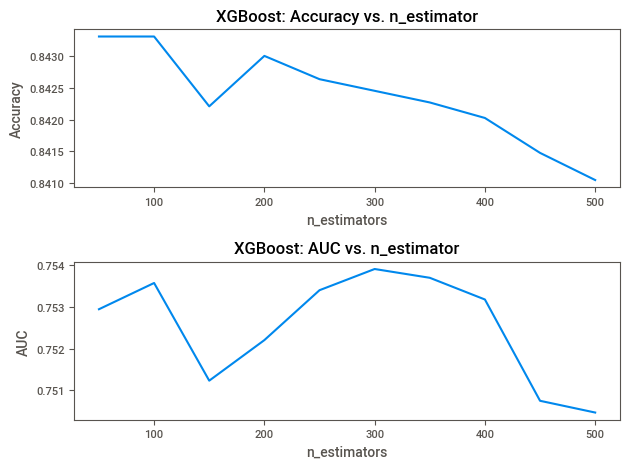

Optimal estimator and XGBoost Accuracy: ( 50 , 0.8433142927338616 )
Optimal estimator and XGBoost AUC: ( 300 , 0.7539082793709818 )


In [ ]:
#Plotting line graphs for Accuracy vs.n_estimator, and AUC Vs.n_estimator

fig, (ax1, ax2) = plt.subplots(2)

ax1.plot(n_estimator_options, accuracy_results)
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.set_title('XGBoost: Accuracy vs. n_estimator')

ax2.plot(n_estimator_options, auc_results)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('AUC')
ax2.set_title('XGBoost: AUC vs. n_estimator')

plt.tight_layout()
plt.show()

#Storing best XGboost accuacy and auc scores
best_XGB_accuracy = max(accuracy_results)
best_XGB_auc = max(auc_results)

#Printing best accuracy and auc and its respective estimator value
print("Optimal estimator and XGBoost Accuracy: (", n_estimator_options[accuracy_results.index(best_XGB_accuracy)], ',', best_XGB_accuracy, ")")
print("Optimal estimator and XGBoost AUC: (", n_estimator_options[auc_results.index(best_XGB_auc)], ',', best_XGB_auc, ")")

#### Observations about the XGBoost Classifier’s behavior with respect to the number of estimators.
*   Like Gradient Boosting, the accuracy is at its highest with 50 estimators then begins decreasing as more trees get added, with 500 being its lowest. AUC follows a slightly different pattern where it dips at 150, rises to its highest point around 300 estimators, and then declines after that. Overall, performance is relatively stable in the mid-range but clearly weakens at higher estimator values.

#### Optimal value of the estimator within the given range?
*   An optimal value would be around 300 estimators, since AUC is at its peak at 300 and accuracy remains competitive, offering a balanced tradeoff before the performance begins degrading.


_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### **Highest Accuracy and AUC Score for each Algorithm**

In [ ]:
#Building a Table to record results
performance_df = pd.DataFrame(
    index=["Accuracy", "AUC"],
    columns=["Random Forest", "Gradient Boost", "AdaBoost", "XGBoost"])

#Filling in the table
performance_df.loc["Accuracy"] = [best_rf_accuracy, best_gb_accuracy, best_AdaB_accuracy, best_XGB_accuracy]
performance_df.loc["AUC"] = [best_rf_auc, best_gb_auc, best_AdaB_auc, best_XGB_auc]

print(performance_df)

         Random Forest Gradient Boost  AdaBoost   XGBoost
Accuracy      0.841902       0.846078  0.844174  0.843314
AUC           0.751807       0.758764  0.757686  0.753908
